# 04 Agrupamiento climatico de municipios del Magdalena

Version simplificada, para el Magdalena, de la idea del articulo *Analysis of Dengue
Prediction Generalization at Municipal Level in Colombia Using Climate-Based Clustering*.

No se replica el pipeline de pronostico. Solo se responde:

- Con las variables climaticas de cada municipio, ¿cuantos grupos encuentra K-Means y como los arma?
- ¿Coincide ese agrupamiento con la division administrativa en subregiones (`subregiones.csv`)?

Fuente climatica: ERA5 diario por municipio, descargado sobre la coordenada de la cabecera
municipal (DIVIPOLA), no sobre el centroide del poligono. Cartografia: geojson municipal DANE.

# 1 Configuracion

In [2]:
import time
import unicodedata
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

import openmeteo_requests
import requests_cache
from retry_requests import retry

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, adjusted_rand_score

ROOT = Path.cwd()
ROOT = ROOT.parent if ROOT.name == "notebooks" else ROOT
DATA = ROOT / "data"

RANDOM_STATE = 42
START_DATE = "2007-01-01"
END_DATE = "2024-12-31"
plt.rcParams["figure.dpi"] = 110

def norm(s):
    return unicodedata.normalize("NFKD", str(s)).encode("ascii", "ignore").decode().upper().strip()

# cliente Open-Meteo, mismo patron del notebook 02
om_session = retry(
    requests_cache.CachedSession(".cache_openmeteo", expire_after=-1),
    retries=5,
    backoff_factor=0.3,
)
om_client = openmeteo_requests.Client(session=om_session)

## Coordenada de referencia por municipio

La coordenada de consulta de cada municipio es la cabecera municipal del DIVIPOLA del DANE, no el
centroide del poligono. En municipios que se extienden desde la costa o el llano hasta la Sierra
Nevada, como Santa Marta, Cienaga, Fundacion y Aracataca, el centroide cae en la montaña y devuelve
un clima frio que no corresponde a la zona poblada. La cabecera ubica el punto donde vive la gente y
donde ocurre la transmision.

El centroide del poligono se calcula solo como respaldo, para municipios sin cabecera registrada. En
el Magdalena los treinta municipios tienen cabecera, asi que el respaldo no llega a activarse.

In [3]:
# coordenada preferida: cabecera municipal del DIVIPOLA (Tipo CM)
divipola = pd.read_csv(DATA / "raw" / "DIVIPOLA-Codigos_cabeceras-Centros_poblados.csv")
cabecera = divipola[
    (divipola["Código Departamento"].astype(str).str.zfill(2) == "47")
    & (divipola["Tipo*"] == "CM")
].rename(columns={
    "Codigo Municipio": "cod_municipio",
    "Nombre Municipio": "municipio",
    "Latitud": "lat",
    "longitud": "lon",
}).copy()

for col in ["lat", "lon"]:
    cabecera[col] = pd.to_numeric(cabecera[col].astype(str).str.replace(",", "."), errors="coerce")
cabecera["cod_municipio"] = cabecera["cod_municipio"].astype(int)
cabecera["municipio"] = cabecera["municipio"].map(norm)
cabecera["fuente_coord"] = "cabecera"

# respaldo: centroide del poligono, solo para municipios sin cabecera
gdf_mag = gpd.read_file(DATA / "raw" / "MGN_ADM_MPIO_GRAFICO.geojson")
gdf_mag = gdf_mag[gdf_mag["dpto_ccdgo"] == "47"].copy()
gdf_mag["cod_municipio"] = gdf_mag["mpio_cdpmp"].astype(int)
centroide = gdf_mag.to_crs(epsg=3116).geometry.centroid.to_crs(epsg=4326)
gdf_mag["lat"] = centroide.y
gdf_mag["lon"] = centroide.x
gdf_mag["municipio"] = gdf_mag["mpio_cnmbr"].map(norm)
gdf_mag["fuente_coord"] = "centroide"

faltan_cabecera = gdf_mag[~gdf_mag["cod_municipio"].isin(cabecera["cod_municipio"])]
cols_coord = ["cod_municipio", "municipio", "lat", "lon", "fuente_coord"]
coords = (
    pd.concat([cabecera[cols_coord], faltan_cabecera[cols_coord]], ignore_index=True)
    .sort_values("cod_municipio")
    .reset_index(drop=True)
)

print("coordenadas por fuente:", coords["fuente_coord"].value_counts().to_dict())
coords

coordenadas por fuente: {'cabecera': 30}


,cod_municipio,municipio,lat,lon,fuente_coord
0,47001,SANTA MARTA,11.204679,-74.199829,cabecera
1,47030,ALGARROBO,10.188059,-74.061132,cabecera
2,47053,ARACATACA,10.589791,-74.186702,cabecera
3,47058,ARIGUANI,9.847047,-74.236515,cabecera
4,47161,CERRO DE SAN ANTONIO,10.325531,-74.868474,cabecera
5,47170,CHIVOLO,10.026631,-74.622242,cabecera
6,47189,CIENAGA,11.006654,-74.241286,cabecera
7,47205,CONCORDIA,10.257314,-74.833030,cabecera
8,47245,EL BANCO,9.008503,-73.974370,cabecera
9,47258,EL PINON,10.402781,-74.823094,cabecera


## Descarga climatica sobre la cabecera

Se descarga ERA5 diario por municipio desde Open-Meteo, el mismo producto y la misma funcion del
notebook 02, cambiando unicamente la coordenada por la de cabecera. De aqui salen las cinco variables
del perfil: temperatura media, maxima y minima, precipitacion y humedad relativa.

El crudo se guarda en un parquet nuevo, separado del que genero el notebook 02 con centroides, para
poder comparar ambas versiones. La primera corrida tarda unos minutos por el limite de peticiones de
Open-Meteo; despues se lee del cache.

In [4]:
def get_era5_diario(lat, lon, start=START_DATE, end=END_DATE):
    res = om_client.weather_api(
        "https://archive-api.open-meteo.com/v1/archive",
        params={
            "latitude": lat,
            "longitude": lon,
            "start_date": start,
            "end_date": end,
            "daily": [
                "temperature_2m_mean",
                "temperature_2m_max",
                "temperature_2m_min",
                "precipitation_sum",
                "relative_humidity_2m_mean",
            ],
            "models": "era5",
            "timezone": "America/Bogota",
        },
    )[0]
    daily = res.Daily()
    fechas = pd.date_range(
        start=pd.to_datetime(daily.Time(), unit="s", utc=True),
        end=pd.to_datetime(daily.TimeEnd(), unit="s", utc=True),
        freq=pd.Timedelta(seconds=daily.Interval()),
        inclusive="left",
    ).tz_localize(None).normalize()
    df = pd.DataFrame({
        "fecha": fechas,
        "t2m_media": daily.Variables(0).ValuesAsNumpy(),
        "t2m_max": daily.Variables(1).ValuesAsNumpy(),
        "t2m_min": daily.Variables(2).ValuesAsNumpy(),
        "precipitacion": daily.Variables(3).ValuesAsNumpy(),
        "humedad": daily.Variables(4).ValuesAsNumpy(),
    })
    df.replace(-999.0, np.nan, inplace=True)
    return df


path_era = DATA / "external" / "clima_era5_magdalena_cabecera_diario.parquet"

if path_era.exists():
    era = pd.read_parquet(path_era)
    era["fecha"] = era["fecha"].dt.normalize()
    print("cargado desde cache:", era.shape)
else:
    partes = []
    for fila in coords.itertuples():
        df = get_era5_diario(fila.lat, fila.lon)
        df["municipio"] = fila.municipio
        df["cod_municipio"] = fila.cod_municipio
        partes.append(df)
        print("OK", fila.municipio)
        time.sleep(18)
    era = pd.concat(partes, ignore_index=True)
    era.to_parquet(path_era, index=False)
    print("guardado:", path_era)

sub = pd.read_csv(DATA / "raw" / "subregiones.csv")
sub["key"] = sub["nombre_municipio"].map(norm)
era["key"] = era["municipio"].map(norm).replace({"CERRO DE SAN ANTONIO": "CERRO SAN ANTONIO"})

print(era["fecha"].min().date(), "->", era["fecha"].max().date(), "|", era["key"].nunique(), "municipios")
sub["subregion"].value_counts()

cargado desde cache: (197250, 8)
2007-01-01 -> 2024-12-31 | 30 municipios


subregion
Rio            9
Sur            7
Norte          7
Centro         6
Santa Marta    1
Name: count, dtype: int64

# 2 Perfil climatico por municipio

Cada municipio se resume por su promedio de largo plazo (2007-2024) en cuatro descriptores:
temperatura media, amplitud termica diaria (max - min), precipitacion y humedad.

In [5]:
era["amplitud"] = era["t2m_max"] - era["t2m_min"]

perfil = (
    era.groupby("key")
    .agg(
        t_media=("t2m_media", "mean"),
        amplitud=("amplitud", "mean"),
        precip=("precipitacion", "mean"),
        humedad=("humedad", "mean"),
    )
    .reset_index()
    .merge(sub, on="key")
)
# precipitacion sesgada a la derecha -> log (como en el articulo)
perfil["log_precip"] = np.log1p(perfil["precip"])
print("sesgo precip:", round(perfil["precip"].skew(), 2))

perfil[["nombre_municipio", "subregion", "t_media", "amplitud", "precip", "humedad"]].round(2)

sesgo precip: 0.3


,nombre_municipio,subregion,t_media,amplitud,precip,humedad
0,Algarrobo,Norte,28.150000,9.59,4.46,76.239998
1,Aracataca,Norte,28.299999,10.12,2.89,74.820000
2,Ariguani,Centro,28.400000,9.92,3.21,73.349998
3,Cerro San Antonio,Rio,28.980000,8.53,2.89,76.720001
4,Chivolo,Centro,27.969999,9.05,4.47,78.940002
5,Cienaga,Norte,27.920000,2.79,5.84,80.449997
6,Concordia,Rio,28.959999,8.53,2.89,76.720001
7,El Banco,Sur,28.600000,6.76,6.20,82.629997
8,El Pinon,Rio,28.719999,8.26,5.15,79.629997
9,El Reten,Norte,28.400000,10.12,2.89,74.830002


# 3 Estructura de las variables

Correlacion entre los cuatro descriptores. Sirve para ver si aportan informacion distinta
o si se reducen a un solo gradiente.

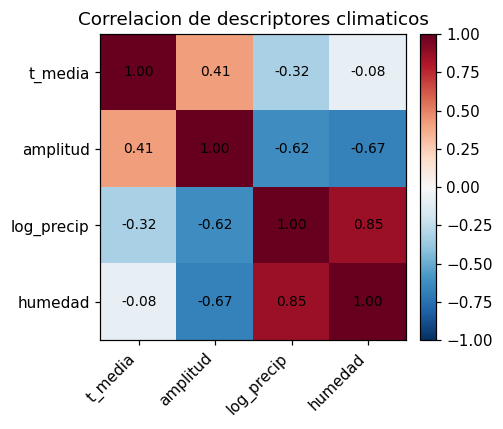

In [6]:
feats = ["t_media", "amplitud", "log_precip", "humedad"]
corr = perfil[feats].corr()

fig, ax = plt.subplots(figsize=(4.6, 4))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(feats))); ax.set_xticklabels(feats, rotation=45, ha="right")
ax.set_yticks(range(len(feats))); ax.set_yticklabels(feats)
for i in range(len(feats)):
    for j in range(len(feats)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=9)
fig.colorbar(im, fraction=0.046, pad=0.04)
ax.set_title("Correlacion de descriptores climaticos")
plt.tight_layout(); plt.show()

Temperatura, precipitacion y humedad estan fuertemente correlacionadas: describen un mismo
gradiente (zonas frias-humedas de la Sierra Nevada frente a tierras bajas calidas-secas).
La amplitud termica es el descriptor mas independiente.

# 4 K-Means: ¿cuantos grupos?

Se estandarizan las variables y se barre K de 2 a 7. Se usa el codo (inercia), el coeficiente
de silueta y el indice Davies-Bouldin para decidir el numero de grupos.

In [7]:
feats_cluster = ["t_media", "amplitud", "log_precip"]
X = StandardScaler().fit_transform(perfil[feats_cluster])

rows = []
for k in range(2, 8):
    km = KMeans(n_clusters=k, n_init=25, random_state=RANDOM_STATE).fit(X)
    rows.append({
        "k": k,
        "inercia": km.inertia_,
        "silueta": silhouette_score(X, km.labels_),
        "davies_bouldin": davies_bouldin_score(X, km.labels_),
    })
barrido = pd.DataFrame(rows).set_index("k")
barrido.round(3)

,inercia,silueta,davies_bouldin
k,,,
2,48.726,0.418,0.935
3,26.579,0.503,0.717
4,13.377,0.580,0.519
5,9.346,0.590,0.500
6,6.582,0.571,0.655
7,5.231,0.576,0.410


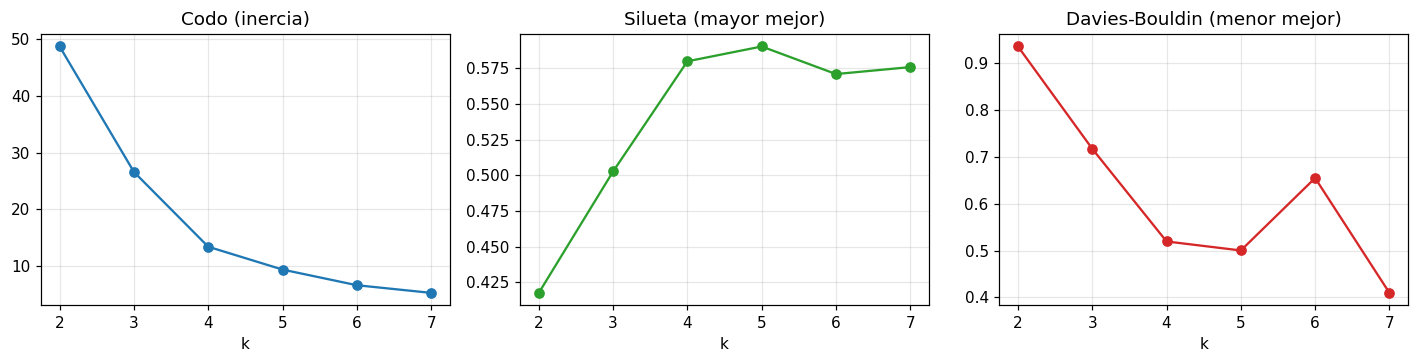

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
axes[0].plot(barrido.index, barrido["inercia"], "o-"); axes[0].set_title("Codo (inercia)")
axes[1].plot(barrido.index, barrido["silueta"], "o-", color="#2ca02c"); axes[1].set_title("Silueta (mayor mejor)")
axes[2].plot(barrido.index, barrido["davies_bouldin"], "o-", color="#d62728"); axes[2].set_title("Davies-Bouldin (menor mejor)")
for ax in axes:
    ax.set_xlabel("k"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [9]:
# eleccion: mejor silueta en el rango interpretable 3-5 (evita fragmentar 30 municipios)
K = int(barrido.loc[3:5, "silueta"].idxmax())
print("K seleccionado:", K)

K seleccionado: 5


# 5 Asignacion y caracterizacion de los grupos

In [10]:
km = KMeans(n_clusters=K, n_init=25, random_state=RANDOM_STATE).fit(X)
perfil["cluster"] = km.labels_

carac = perfil.groupby("cluster")[["t_media", "amplitud", "precip", "humedad"]].mean()
carac["n"] = perfil["cluster"].value_counts().sort_index()

carac.round(2)

,t_media,amplitud,precip,humedad,n
cluster,,,,,
0,28.950001,8.37,3.21,77.550003,8
1,28.120001,9.15,4.89,78.050003,3
2,28.620001,7.20,6.31,81.139999,11
3,27.879999,2.79,5.84,80.440002,3
4,28.420000,10.08,2.89,74.180000,5


In [11]:
for c in sorted(perfil["cluster"].unique()):
    ms = perfil.loc[perfil["cluster"] == c, "nombre_municipio"].tolist()  #type: ignore
    print(f"Cluster {c} ({len(ms)}): {', '.join(ms)}") #type: ignore

Cluster 0 (8): Cerro San Antonio, Concordia, Pedraza, Pivijay, Plato, Santa Barbara de Pinto, Tenerife, Zapayan
Cluster 1 (3): Algarrobo, Chivolo, Nueva Granada
Cluster 2 (11): El Banco, El Pinon, Guamal, Pijino del Carmen, Remolino, Salamina, San Sebastian de Buenavista, San Zenon, Santa Ana, Sitionuevo, Zona Bananera
Cluster 3 (3): Cienaga, Puebloviejo, Santa Marta
Cluster 4 (5): Aracataca, Ariguani, El Reten, Fundacion, Sabanas de San Angel


# 6 Subregiones administrativas vs K-Means

Tabla de contingencia y el indice Rand ajustado (ARI): mide cuanto coinciden ambas
particiones (1 = identicas, 0 = coincidencia aleatoria).

In [12]:
ct = pd.crosstab(perfil["subregion"], perfil["cluster"])
sub_codes = perfil["subregion"].astype("category").cat.codes
ari = adjusted_rand_score(sub_codes, perfil["cluster"])
print("ARI (subregion vs K-Means):", round(ari, 3))
ct

ARI (subregion vs K-Means): 0.225


cluster,0,1,2,3,4
subregion,,,,,
Centro,2,2,0,0,2
Norte,0,1,1,2,3
Rio,5,0,4,0,0
Santa Marta,0,0,0,1,0
Sur,1,0,6,0,0


## 6.1 Los dos mapas

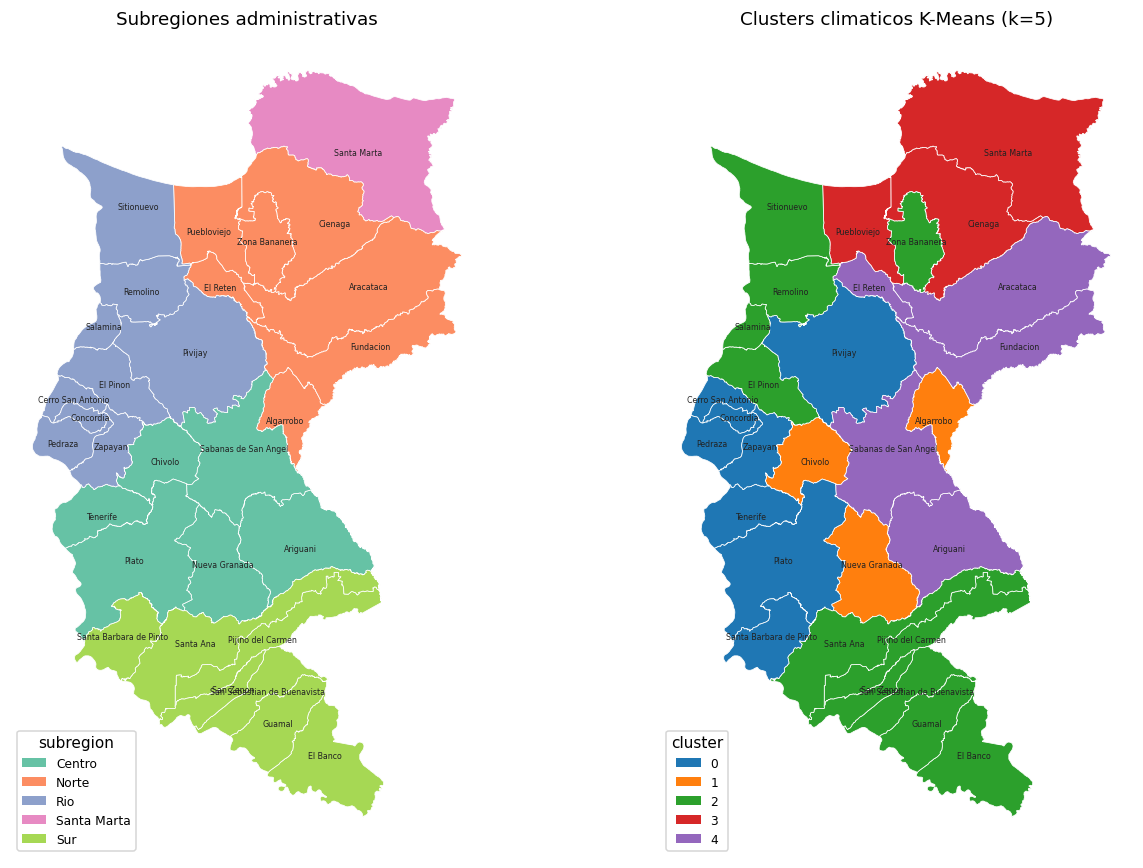

In [13]:
gdf = gpd.read_file(DATA / "raw" / "MGN_ADM_MPIO_GRAFICO.geojson")
mag = gdf[gdf["dpto_ccdgo"] == "47"].copy()
mag["cod_municipio"] = mag["mpio_cdpmp"].astype(int)
mag = mag.merge(perfil, on="cod_municipio")

# colores
subs = sorted(perfil["subregion"].unique())
sub_cmap = dict(zip(subs, plt.cm.Set2.colors))
clu = sorted(perfil["cluster"].unique())
clu_cmap = dict(zip(clu, plt.cm.tab10.colors))
mag["c_sub"] = mag["subregion"].map(sub_cmap)
mag["c_clu"] = mag["cluster"].map(clu_cmap)

fig, axes = plt.subplots(1, 2, figsize=(13, 8))

mag.plot(ax=axes[0], color=mag["c_sub"], edgecolor="white", linewidth=0.5)
axes[0].set_title("Subregiones administrativas")
axes[0].legend(handles=[Patch(facecolor=sub_cmap[s], label=s) for s in subs],
               loc="lower left", fontsize=8, title="subregion")

mag.plot(ax=axes[1], color=mag["c_clu"], edgecolor="white", linewidth=0.5)
axes[1].set_title(f"Clusters climaticos K-Means (k={K})")
axes[1].legend(handles=[Patch(facecolor=clu_cmap[c], label=f"{c}") for c in clu],
               loc="lower left", fontsize=8, title="cluster")

# etiquetas de municipio
for ax in axes:
    for _, r in mag.iterrows():
        pt = r.geometry.representative_point()
        ax.annotate(r["nombre_municipio"], (pt.x, pt.y), fontsize=5.2,
                    ha="center", va="center", color="#222")
    ax.set_axis_off()
plt.tight_layout(); plt.show()

# 7 Espacio climatico

Los municipios en el plano temperatura-precipitacion. Color = cluster K-Means, marcador =
subregion administrativa. Si ambos coincidieran, cada color caeria dentro de un solo marcador.

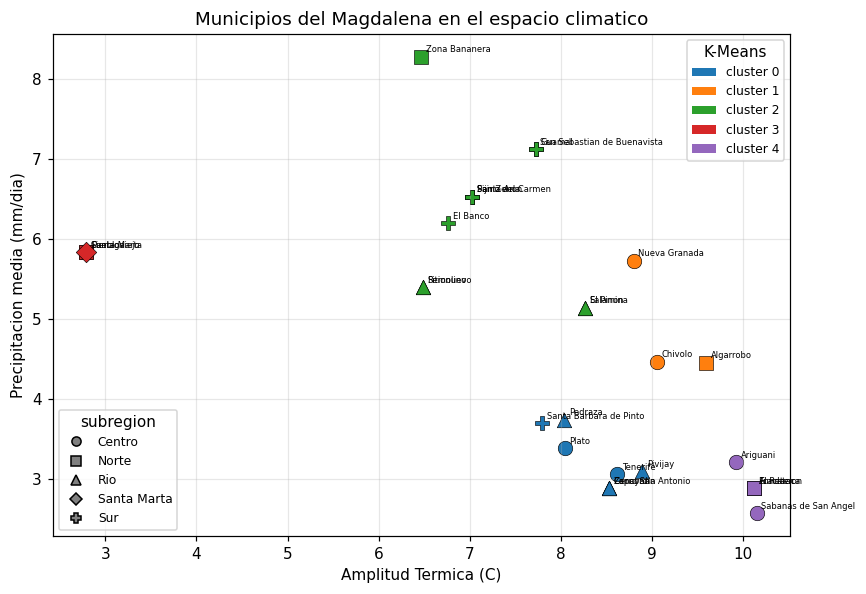

In [14]:
markers = ["o", "s", "^", "D", "P"]
sub_mk = dict(zip(subs, markers))

fig, ax = plt.subplots(figsize=(8, 5.5))
for _, r in perfil.iterrows():
    ax.scatter(r["amplitud"], r["precip"], color=clu_cmap[r["cluster"]],
               marker=sub_mk[r["subregion"]], s=90, edgecolor="k", linewidth=0.4)
    ax.annotate(r["nombre_municipio"], (r["amplitud"], r["precip"]), fontsize=5.5,
                xytext=(3, 3), textcoords="offset points")
ax.set_xlabel("Amplitud Termica (C)"); ax.set_ylabel("Precipitacion media (mm/dia)")
ax.set_title("Municipios del Magdalena en el espacio climatico")

leg1 = ax.legend(handles=[Patch(facecolor=clu_cmap[c], label=f"cluster {c}") for c in clu],
                 loc="upper right", fontsize=8, title="K-Means")
ax.add_artist(leg1)
ax.legend(handles=[plt.Line2D([], [], marker=sub_mk[s], color="gray", linestyle="",
                              markeredgecolor="k", label=s) for s in subs],
          loc="lower left", fontsize=8, title="subregion")
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [21]:

medias_por_cluster = carac.round(2)

print(medias_por_cluster)

           t_media  amplitud  precip    humedad   n
cluster                                            
0        28.950001      8.37    3.21  77.550003   8
1        28.120001      9.15    4.89  78.050003   3
2        28.620001      7.20    6.31  81.139999  11
3        27.879999      2.79    5.84  80.440002   3
4        28.420000     10.08    2.89  74.180000   5


# 8 Hallazgos

Los hallazgos anteriores se derivaron de coordenadas de centroide y quedaron obsoletos al corregir la
extraccion a cabecera municipal. Deben reescribirse despues de ejecutar el notebook con los datos
nuevos, tomando los resultados reales y no los previos.

Cluster 3 (Ciénaga, Puebloviejo, Santa Marta). Su firma es la amplitud de 2.79, menos de la mitad que cualquier otro grupo. Son la franja costera del Caribe y el borde de la Ciénaga Grande de Santa Marta, y el mar y la laguna amortiguan la oscilación diaria de temperatura. Climáticamente el casco de Santa Marta es semiárido cálido tropical BShx en la clasificación de Köppen, o sea seco, no húmedo. Ojo con esto: ERA5 le asigna precipitación y humedad altas porque el píxel de 31 km cerca de la costa mezcla la humedad marina

Cluster 2 (El Banco, El Piñón, Guamal, Pijiño, Remolino, Salamina, San Sebastián, San Zenón, Santa Ana, Sitionuevo, Zona Bananera). Tiene la precipitación más alta (6.31) y la humedad más alta (81.14). Son los municipios pegados al agua: la depresión Momposina y el brazo de Mompós al sur, el borde de la Ciénaga Grande, y la Zona Bananera al pie de la Sierra. Guamal, por ejemplo, está en la margen oriental del brazo de Mompós, rodeado por la ciénaga de Chilloa. Es la transición del bosque seco al húmedo tropical.

Cluster 0 (Cerro San Antonio, Concordia, Pedraza, Pivijay, Plato, Santa Bárbara de Pinto, Tenerife, Zapayán). Es el más caliente (28.95), seco (precip 3.21) y de amplitud media-alta. Son la ribera occidental del Magdalena y la llanura seca, bosque seco tropical clásico, la zona que la climatología ubica como clima seco del valle del Magdalena, de sabana y estepario cálido.

Cluster 4 (Aracataca, Ariguaní, El Retén, Fundación, Sabanas de San Ángel). El extremo del gradiente seco: amplitud 10.08 (la mayor), precipitación 2.89 (la menor) y humedad 74.18 (la menor). Son el piedemonte seco de la Sierra Nevada más la sabana interior, la zona más continental, donde el aire es más seco. Encaja con la humedad caribeña baja, que la climatología nacional sitúa en torno al 70 por ciento o menos en el Caribe y La Guajira.

Cluster 1 (Algarrobo, Chivolo, Nueva Granada). Es intermedio en todo: precipitación 4.89, entre el occidente seco y la ribera húmeda, con amplitud alta. Geográficamente es el interior central, la bisagra entre ambos.